In [40]:
import numpy as np
import pandas as pd

In [41]:
df = pd.read_csv(r"Data\newplacementdata - newplacementdata.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


<Axes: xlabel='placement_exam_marks'>

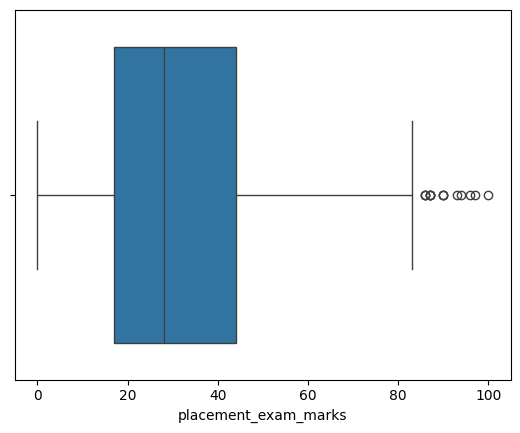

In [44]:
sns.boxplot(x = df['placement_exam_marks'])

In [45]:
## Finding Outliers Range
q3 = df['placement_exam_marks'].quantile(0.75)
q1 = df['placement_exam_marks'].quantile(0.25)

IQR = q3 - q1
print("Inter Quartile Range: ", IQR)

Inter Quartile Range:  27.0


In [46]:
upper_fence = q3 + 1.5 * (IQR)
lower_fence = q1 - 1.5 * (IQR)

print("Upper Limit:", upper_fence)
print("Lower Limit", lower_fence)

Upper Limit: 84.5
Lower Limit -23.5


## Trimming

In [47]:
df[df['placement_exam_marks'] > upper_fence]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [48]:
df[df['placement_exam_marks'] < lower_fence]

,cgpa,placement_exam_marks,placed


In [49]:
new_df = df[df['placement_exam_marks'] < upper_fence]

<Axes: xlabel='placement_exam_marks'>

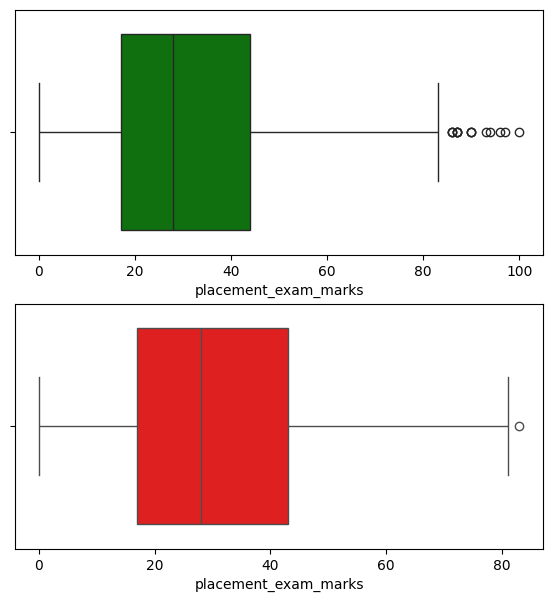

In [50]:
plt.figure(figsize= (15,7))

plt.subplot(222)
sns.boxplot(x = df['placement_exam_marks'], color='g')

plt.subplot(224)
sns.boxplot(x = new_df['placement_exam_marks'], color='r')

## Capping

In [51]:
copy_df = df.copy()

<Axes: xlabel='placement_exam_marks'>

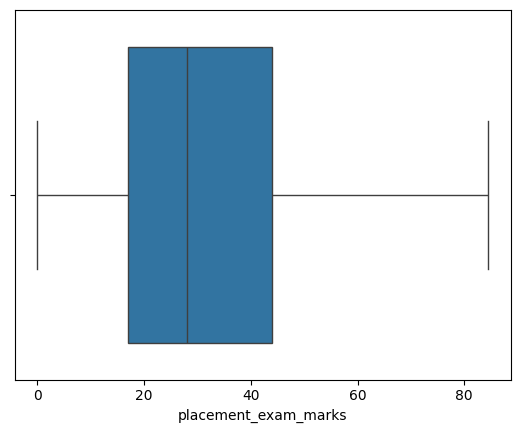

In [52]:
copy_df['placement_exam_marks'] = copy_df['placement_exam_marks'].clip(lower_fence, upper_fence)

sns.boxplot(x = copy_df['placement_exam_marks'])

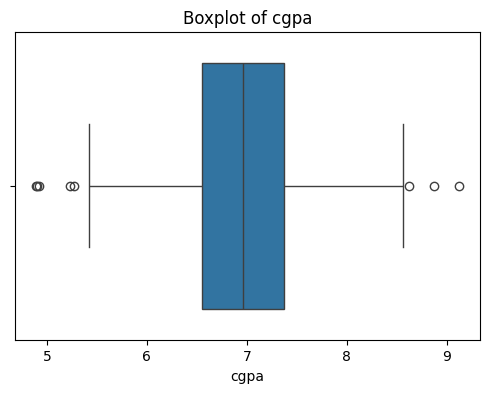

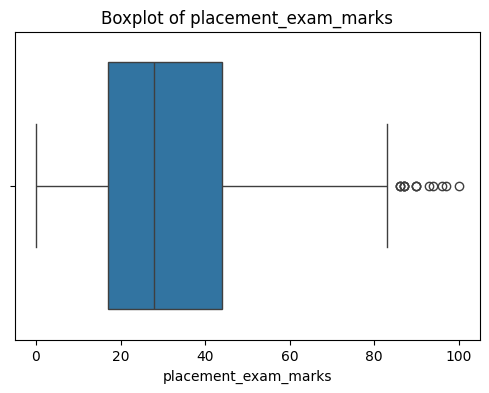

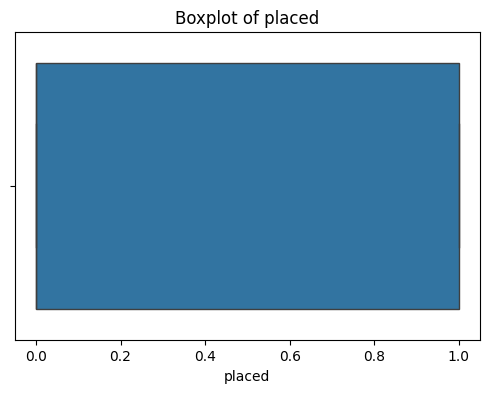

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
num_col = df.select_dtypes(include=['number']).columns

for column in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [61]:
num_col

Index(['cgpa', 'placement_exam_marks', 'placed'], dtype='str')